# Drought Severity — Data Exploration
**NYCU Data Mining 2026 Final Project**  
Explore the training and test data: distributions, missing values, temporal patterns, feature correlations, and regional drought maps.


## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("husl")

train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')
train['date'] = pd.to_datetime(train['date'], errors='coerce')
test['date']  = pd.to_datetime(test['date'],  errors='coerce')
train = train.sort_values(['region_id', 'date']).reset_index(drop=True)
test  = test.sort_values(['region_id', 'date']).reset_index(drop=True)

print(f"Train : {train.shape[0]:,} rows  |  {train['region_id'].nunique():,} regions")
print(f"Test  : {test.shape[0]:,} rows   |  {test['region_id'].nunique():,} regions")
print(f"\nTrain date range: {train['date'].min().date()} → {train['date'].max().date()}")
print(f"Test  date range: {test['date'].min().date()} → {test['date'].max().date()}")


Train : 12,319,040 rows  |  2,248 regions
Test  : 204,568 rows   |  2,248 regions

Train date range: 3004-12-31 → 8133-12-31
Test  date range: 3020-09-18 → 8135-04-28


## 2. Schema & Missing Values

In [2]:
print("=== TRAIN COLUMNS ===")
print(train.dtypes)
print("\n=== MISSING VALUES (train) ===")
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing if len(missing) else "No missing values")


=== TRAIN COLUMNS ===
region_id                str
date          datetime64[us]
prec                 float64
surf_pre             float64
humidity             float64
tmp                  float64
dp_tmp               float64
wb_tmp               float64
tmp_max              float64
tmp_min              float64
tmp_range            float64
surf_tmp             float64
wind                 float64
wind_max             float64
wind_min             float64
wind_range           float64
score                float64
dtype: object

=== MISSING VALUES (train) ===
date     11590728
score    10561104
dtype: int64


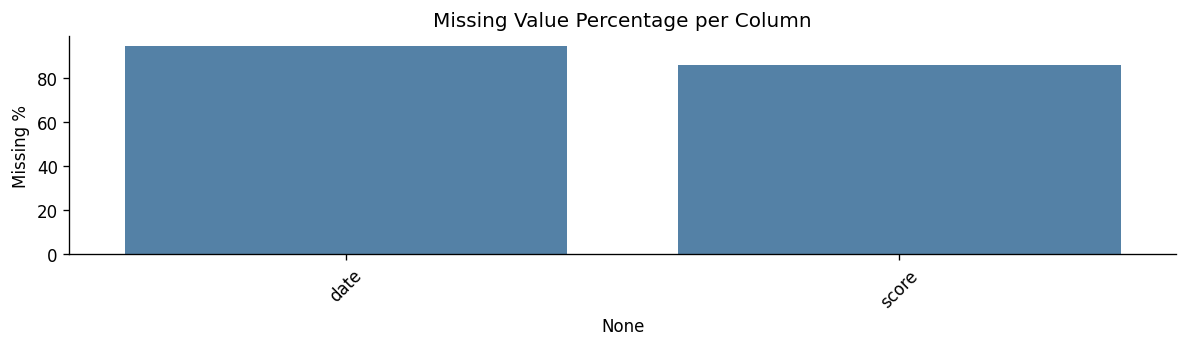

In [3]:
# Visualise missing values as a heatmap
fig, ax = plt.subplots(figsize=(10, 3))
miss_pct = (train.isnull().mean() * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]
if len(miss_pct):
    sns.barplot(x=miss_pct.index, y=miss_pct.values, ax=ax, color='steelblue')
    ax.set_ylabel("Missing %")
    ax.set_title("Missing Value Percentage per Column")
    ax.tick_params(axis='x', rotation=45)
else:
    ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=14)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 3. Target Variable — Score Distribution

In [4]:
scored = train[train['score'].notna()]
print(f"Rows with scores : {len(scored):,}  ({len(scored)/len(train)*100:.1f}% of train)")
print(f"Rows without     : {train['score'].isna().sum():,}")
print(f"\nScore counts:")
print(scored['score'].value_counts().sort_index())


Rows with scores : 1,757,936  (14.3% of train)
Rows without     : 10,561,104

Score counts:
score
0.0    1048333
1.0     303432
2.0     186279
3.0     118496
4.0      69422
5.0      31974
Name: count, dtype: int64


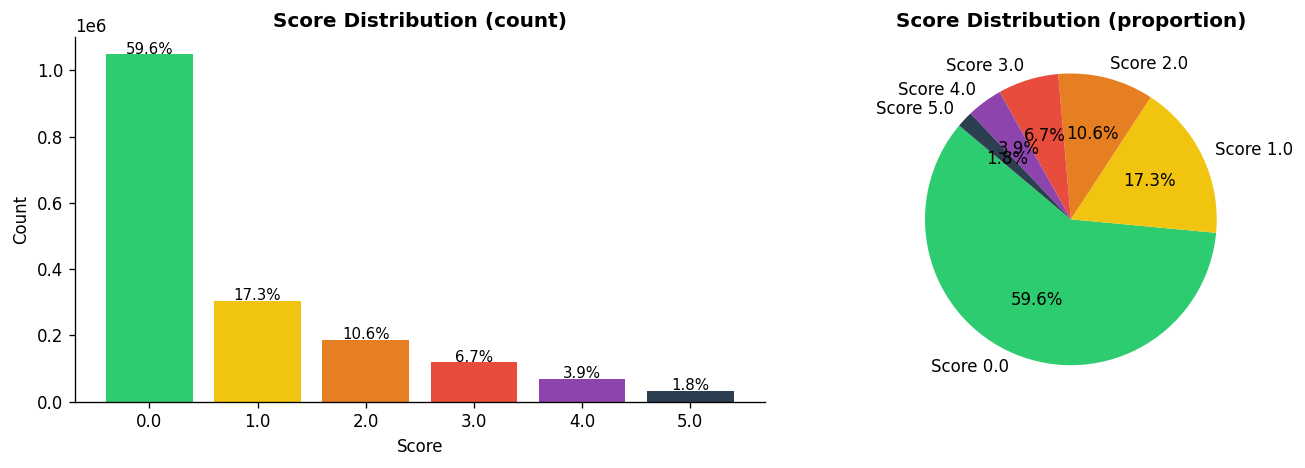

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count bar
vc = scored['score'].value_counts().sort_index()
colors = ['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad','#2c3e50']
axes[0].bar(vc.index.astype(str), vc.values, color=colors[:len(vc)])
axes[0].set_title('Score Distribution (count)', fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 2000, f'{v/len(scored)*100:.1f}%', ha='center', fontsize=9)

# Pie
axes[1].pie(vc.values, labels=[f'Score {s}' for s in vc.index],
            colors=colors[:len(vc)], autopct='%1.1f%%', startangle=140)
axes[1].set_title('Score Distribution (proportion)', fontweight='bold')

plt.tight_layout()
plt.show()


## 4. Feature Statistics

In [6]:
feature_cols = ['wind','wind_min','wind_max','wind_range',
                'humidity','tmp','tmp_range','tmp_max','tmp_min',
                'surf_tmp','surf_pre','dp_tmp','wb_tmp','prec']
print(train[feature_cols].describe().round(3))


               wind      wind_min      wind_max    wind_range      humidity  \
count  1.231904e+07  1.231904e+07  1.231904e+07  1.231904e+07  1.231904e+07   
mean   3.647000e+00  1.949000e+00  5.342000e+00  3.393000e+00  7.800000e+00   
std    1.880000e+00  1.371000e+00  2.657000e+00  1.987000e+00  4.729000e+00   
min    2.500000e-01  0.000000e+00  5.400000e-01  2.000000e-01  1.200000e-01   
25%    2.200000e+00  9.500000e-01  3.240000e+00  1.900000e+00  3.770000e+00   
50%    3.250000e+00  1.680000e+00  4.850000e+00  2.940000e+00  6.760000e+00   
75%    4.710000e+00  2.630000e+00  6.930000e+00  4.420000e+00  1.132000e+01   
max    2.494000e+01  1.720000e+01  3.628000e+01  2.825000e+01  2.292000e+01   

                tmp     tmp_range       tmp_max       tmp_min      surf_tmp  \
count  1.231904e+07  1.231904e+07  1.231904e+07  1.231904e+07  1.231904e+07   
mean   1.294900e+01  1.134500e+01  1.888200e+01  7.537000e+00  1.306800e+01   
std    1.096400e+01  4.053000e+00  1.156400e+01  1.

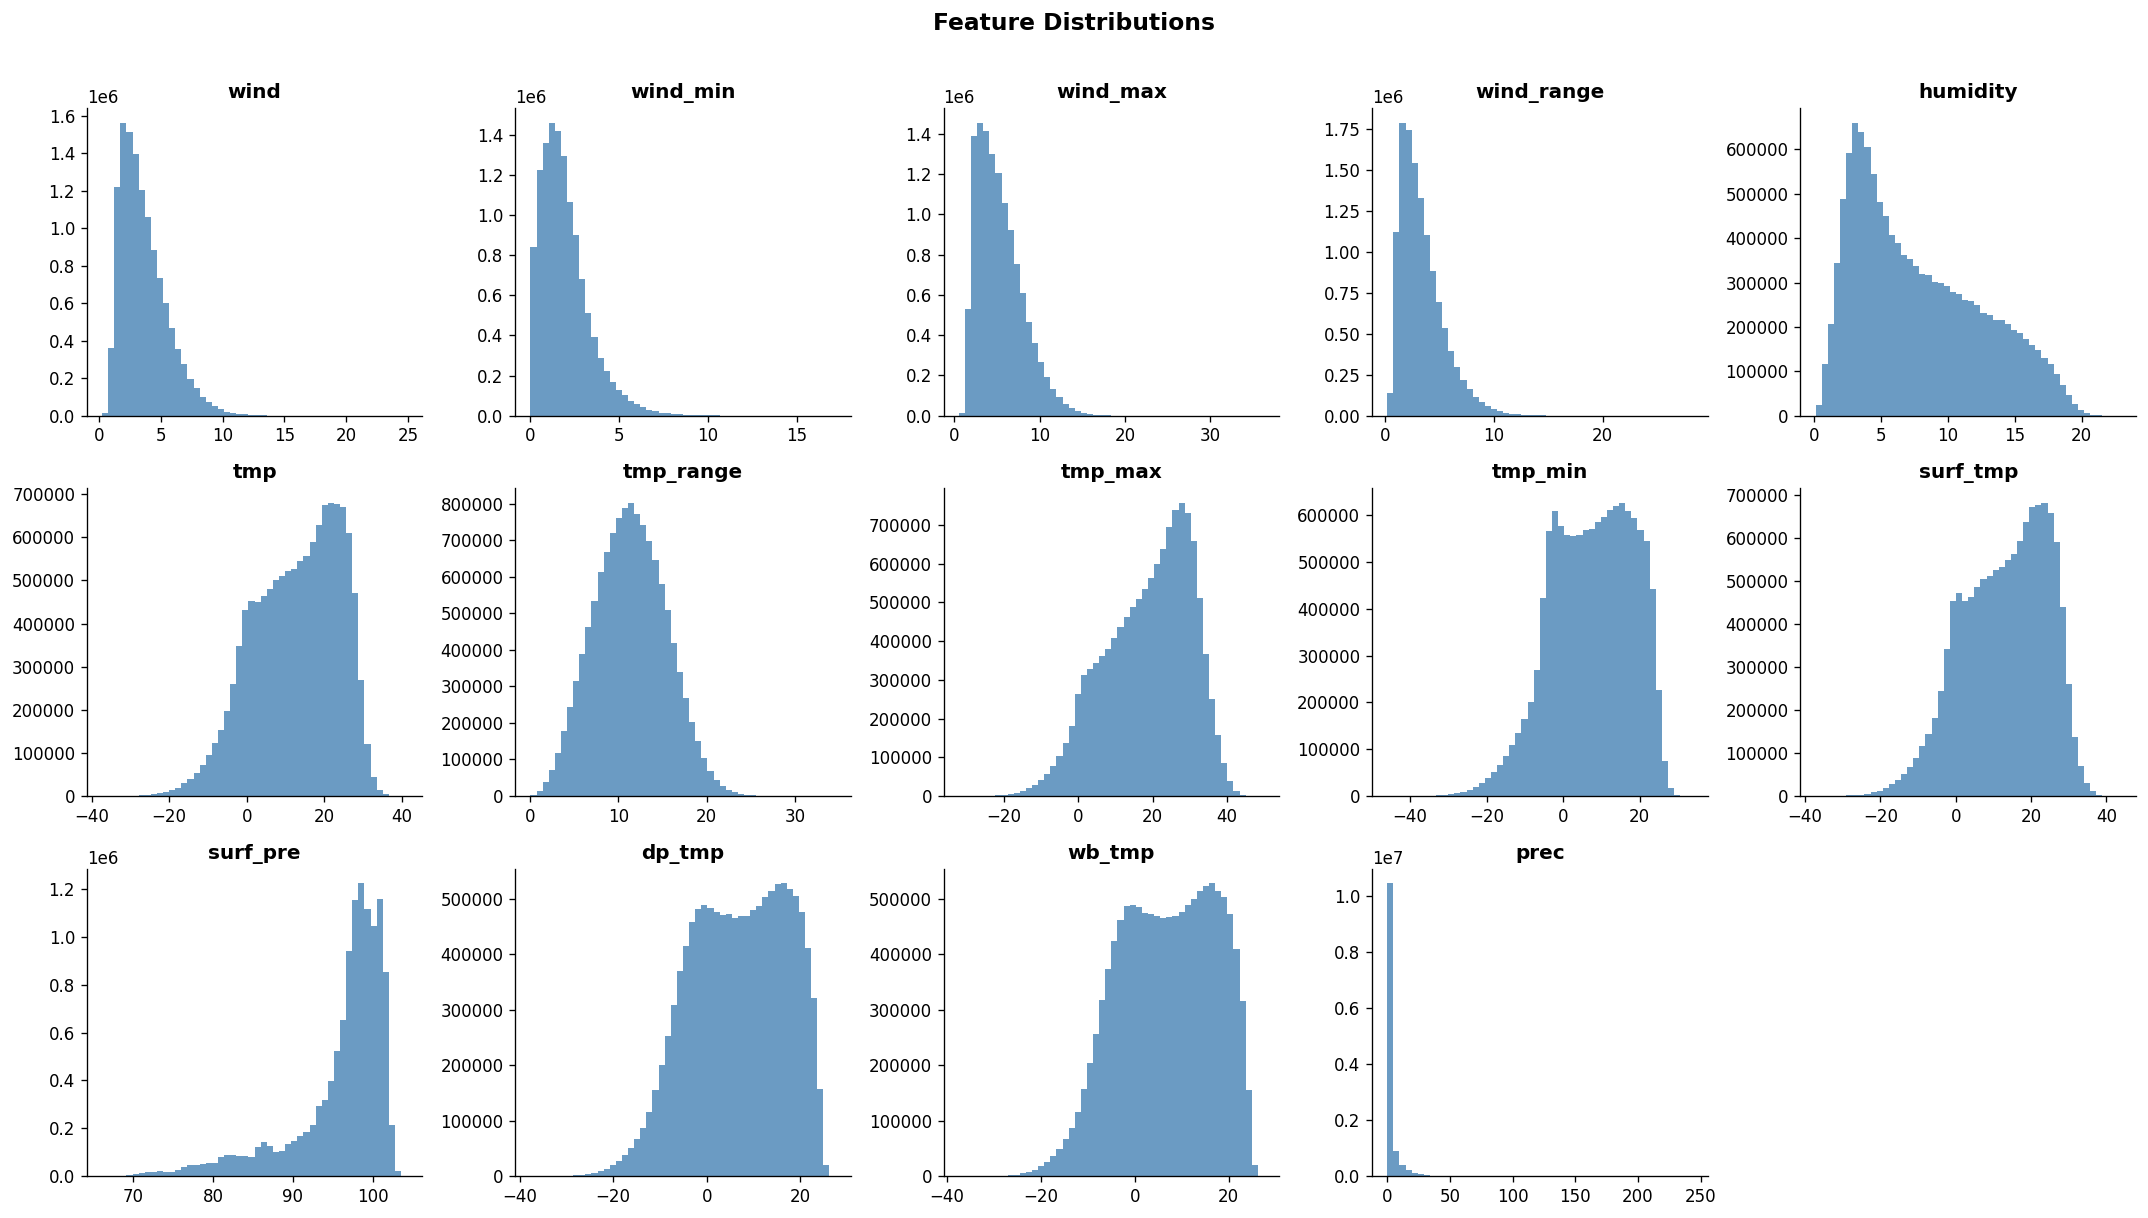

In [7]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].hist(train[col].dropna(), bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 5. Feature vs Score (Box Plots)

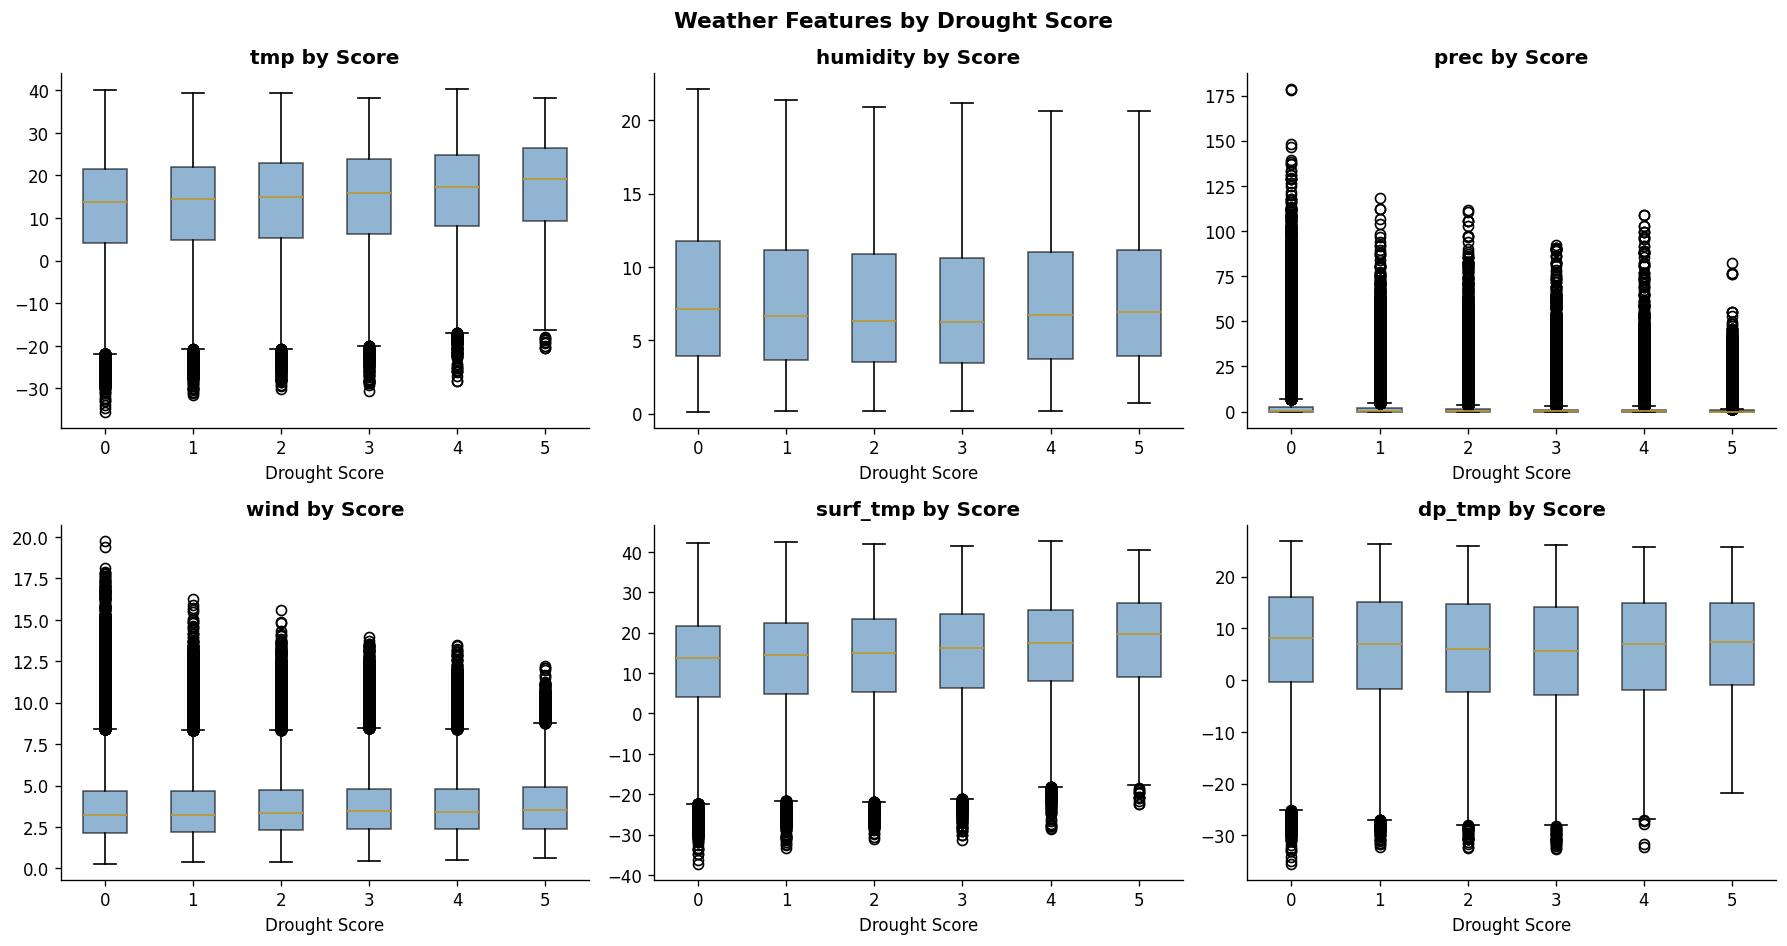

In [8]:
key_feats = ['tmp', 'humidity', 'prec', 'wind', 'surf_tmp', 'dp_tmp']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, feat in enumerate(key_feats):
    data = [scored[scored['score'] == s][feat].dropna() for s in sorted(scored['score'].unique())]
    axes[i].boxplot(data, labels=[str(int(s)) for s in sorted(scored['score'].unique())],
                    patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{feat} by Score', fontweight='bold')
    axes[i].set_xlabel('Drought Score')
plt.suptitle('Weather Features by Drought Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Correlation with Score

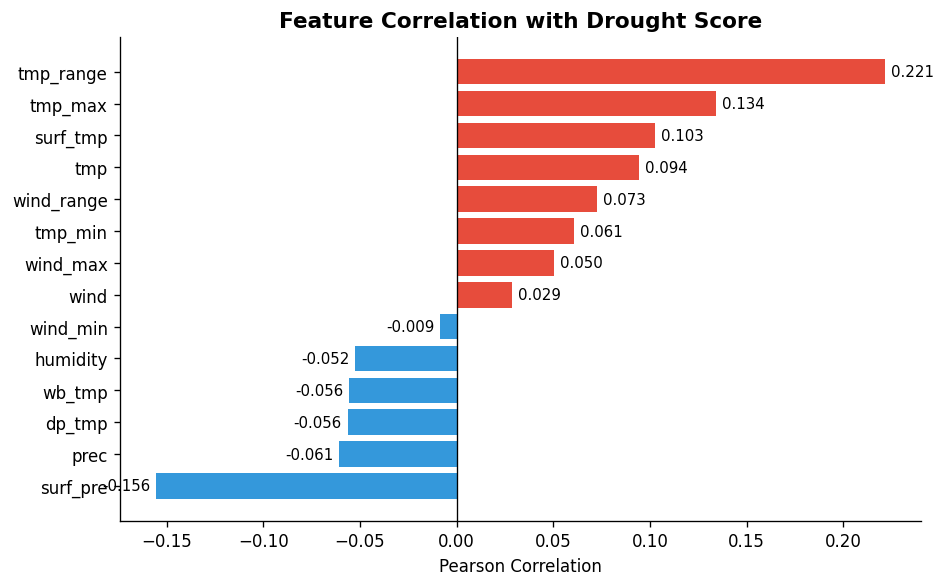

In [9]:
corr_cols = feature_cols + ['score']
corr = scored[corr_cols].corr()['score'].drop('score').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr.values]
bars = ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Drought Score', fontweight='bold', fontsize=13)
ax.set_xlabel('Pearson Correlation')
for bar, val in zip(bars, corr.values):
    ax.text(val + (0.003 if val >= 0 else -0.003), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()


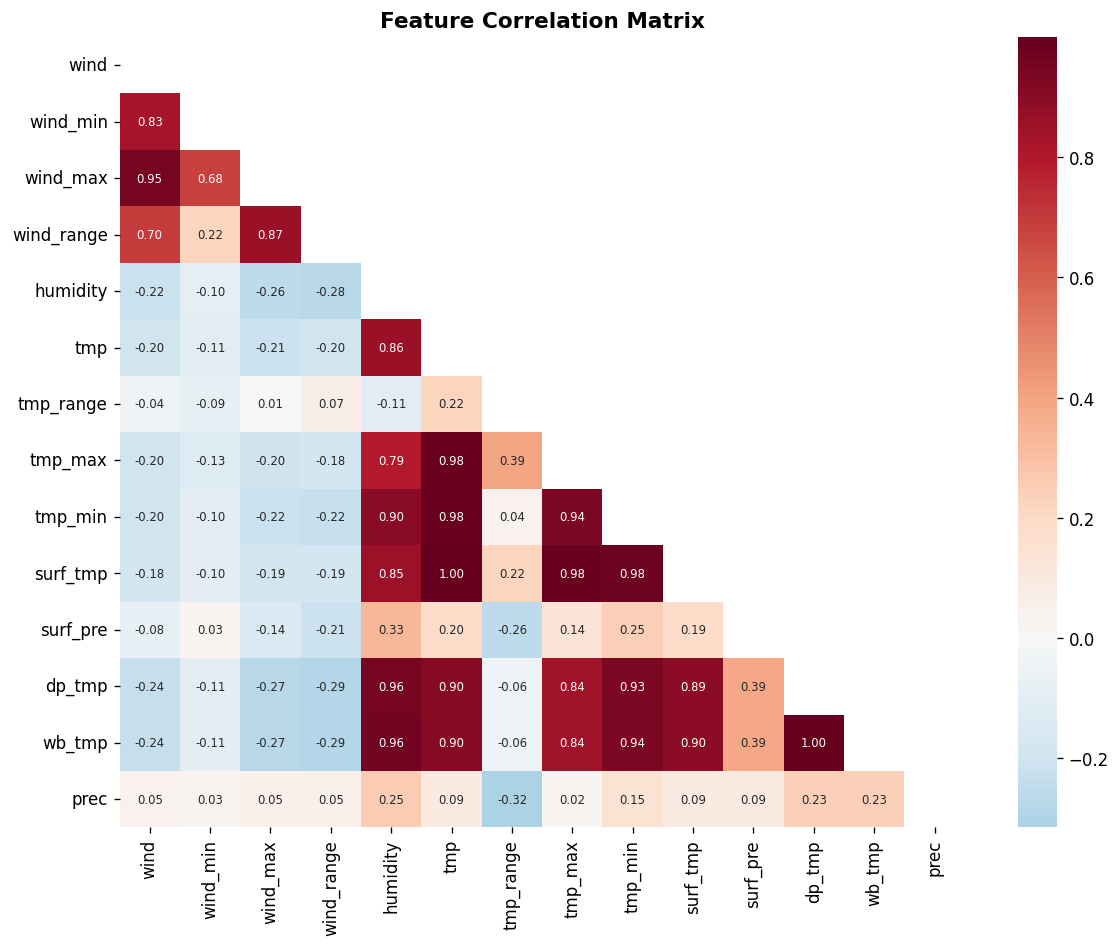

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = scored[feature_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


## 7. Temporal Patterns

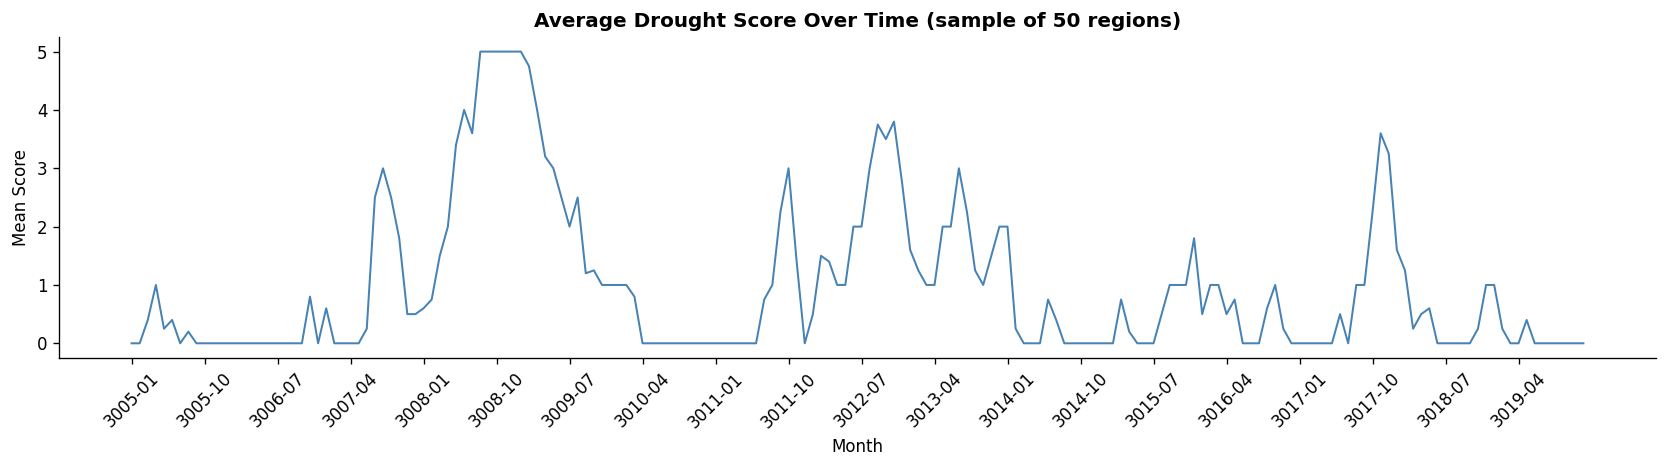

In [11]:
# Average score over time (sample 50 regions for speed)
sample_regions = scored['region_id'].unique()[:50]
sample = scored[scored['region_id'].isin(sample_regions)].copy()
monthly = sample.groupby(sample['date'].dt.to_period('M'))['score'].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly.index.astype(str), monthly.values, color='steelblue', linewidth=1.2)
ax.set_title('Average Drought Score Over Time (sample of 50 regions)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Mean Score')
ax.tick_params(axis='x', rotation=45)
step = max(1, len(monthly) // 20)
ax.set_xticks(range(0, len(monthly), step))
ax.set_xticklabels([str(monthly.index[i]) for i in range(0, len(monthly), step)], rotation=45)
plt.tight_layout()
plt.show()


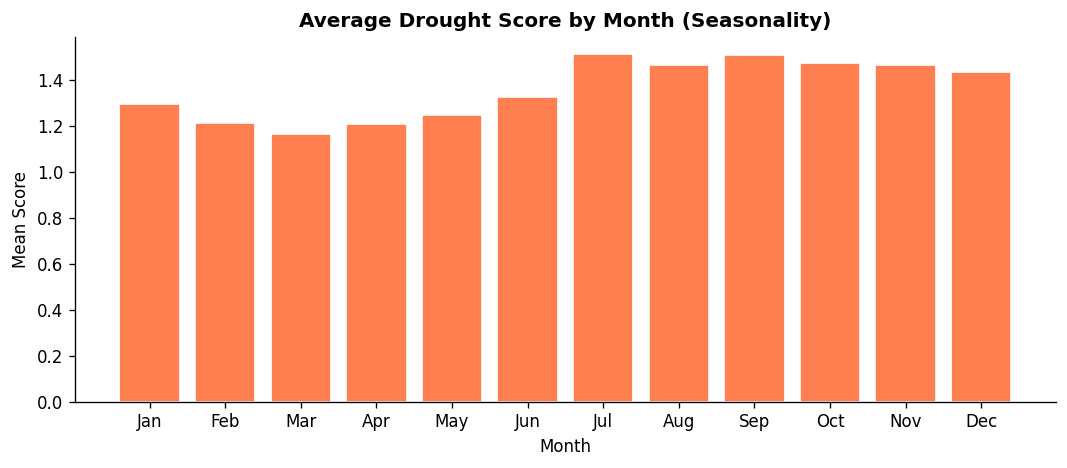

In [12]:
# Score by month of year (seasonality)
scored['month'] = scored['date'].dt.month
monthly_avg = scored.groupby('month')['score'].mean()

fig, ax = plt.subplots(figsize=(9, 4))
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.bar(month_names, monthly_avg.values, color='coral', edgecolor='white')
ax.set_title('Average Drought Score by Month (Seasonality)', fontweight='bold')
ax.set_ylabel('Mean Score')
ax.set_xlabel('Month')
plt.tight_layout()
plt.show()


## 8. Regional Analysis

In [13]:
region_avg = (scored.groupby('region_id')['score']
              .agg(['mean','std','max'])
              .rename(columns={'mean':'avg_score','std':'std_score','max':'max_score'})
              .sort_values('avg_score', ascending=False))

print("Top 20 highest-drought regions:")
print(region_avg.head(20).round(3))
print("\nTop 20 lowest-drought regions:")
print(region_avg.tail(20).round(3))


Top 20 highest-drought regions:
           avg_score  std_score  max_score
region_id                                 
R1714          2.256      1.699        5.0
R1726          2.220      1.689        5.0
R68            2.192      1.286        5.0
R199           2.180      1.864        5.0
R176           2.179      1.792        5.0
R172           2.166      1.855        5.0
R77            2.164      1.220        5.0
R187           2.161      1.783        5.0
R1728          2.156      1.481        4.0
R173           2.155      1.839        5.0
R213           2.142      1.821        5.0
R1727          2.138      1.714        5.0
R197           2.129      1.844        5.0
R2499          2.120      1.780        5.0
R2622          2.091      1.756        5.0
R1723          2.072      1.626        5.0
R2682          2.041      1.794        5.0
R211           2.038      1.849        5.0
R79            2.038      1.113        4.0
R2558          2.037      1.801        5.0

Top 20 lowest-drought

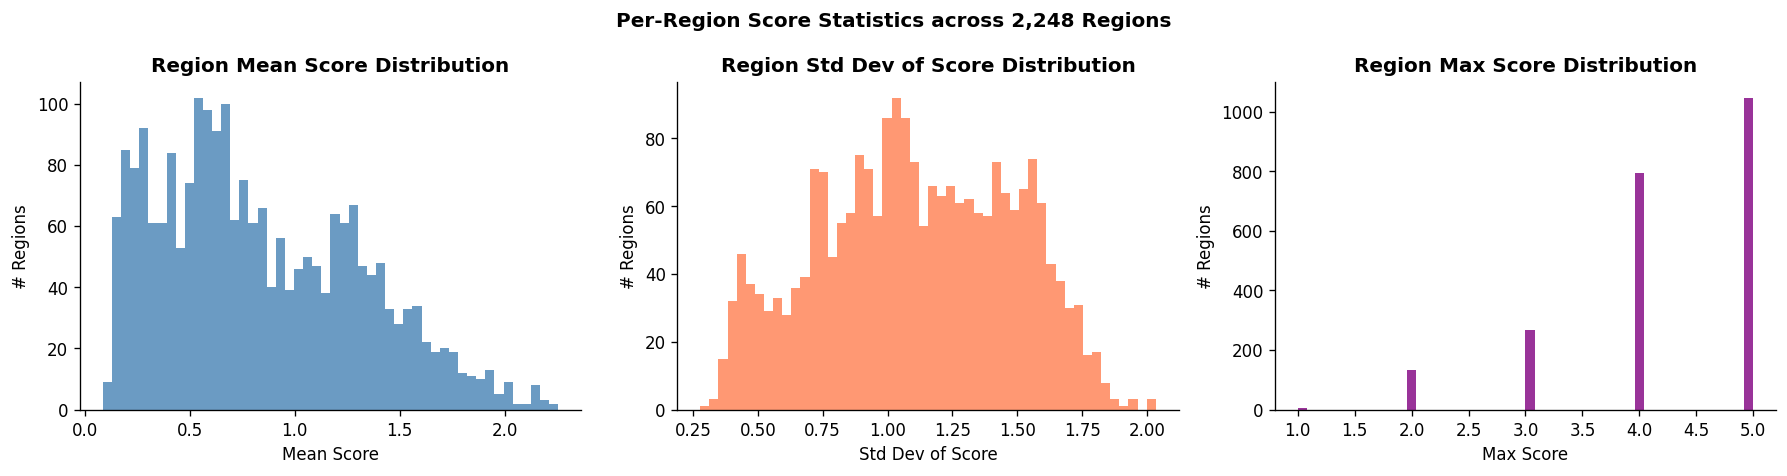

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title, color in zip(axes,
        ['avg_score', 'std_score', 'max_score'],
        ['Mean Score', 'Std Dev of Score', 'Max Score'],
        ['steelblue', 'coral', 'purple']):
    ax.hist(region_avg[col], bins=50, color=color, edgecolor='none', alpha=0.8)
    ax.set_title(f'Region {title} Distribution', fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('# Regions')
plt.suptitle('Per-Region Score Statistics across 2,248 Regions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Weekly Score Pattern

Days between consecutive score records (Region R1):
date
7.0    774
6.0      4
8.0      3
Name: count, dtype: int64


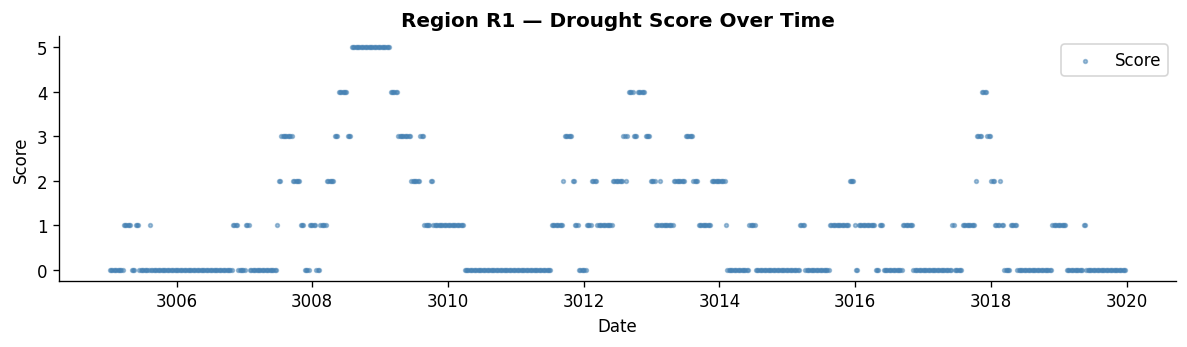

In [15]:
# Verify scores are recorded weekly
r1 = train[train['region_id'] == 'R1'].copy()
score_dates = r1[r1['score'].notna()]['date'].sort_values()
diffs = score_dates.diff().dt.days.dropna().value_counts()
print("Days between consecutive score records (Region R1):")
print(diffs)

fig, ax = plt.subplots(figsize=(10, 3))
ax.scatter(r1['date'], r1['score'], s=5, alpha=0.5, color='steelblue', label='Score')
ax.set_title('Region R1 — Drought Score Over Time', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()


## 10. Train / Test Split Overview

In [16]:
r1_train = train[train['region_id'] == 'R1']
r1_test  = test[test['region_id']   == 'R1']

print(f"Train ends : {r1_train['date'].max().date()}")
print(f"Test starts: {r1_test['date'].min().date()}")
print(f"Test ends  : {r1_test['date'].max().date()}")
gap = (r1_test['date'].min() - r1_train['date'].max()).days
print(f"Gap        : {gap} day(s)")
print(f"Prediction window starts: {r1_test['date'].max().date() + pd.Timedelta(days=1)}")


Train ends : 3019-12-31
Test starts: 3020-09-18
Test ends  : 3020-12-17
Gap        : 262 day(s)
Prediction window starts: 3020-12-18


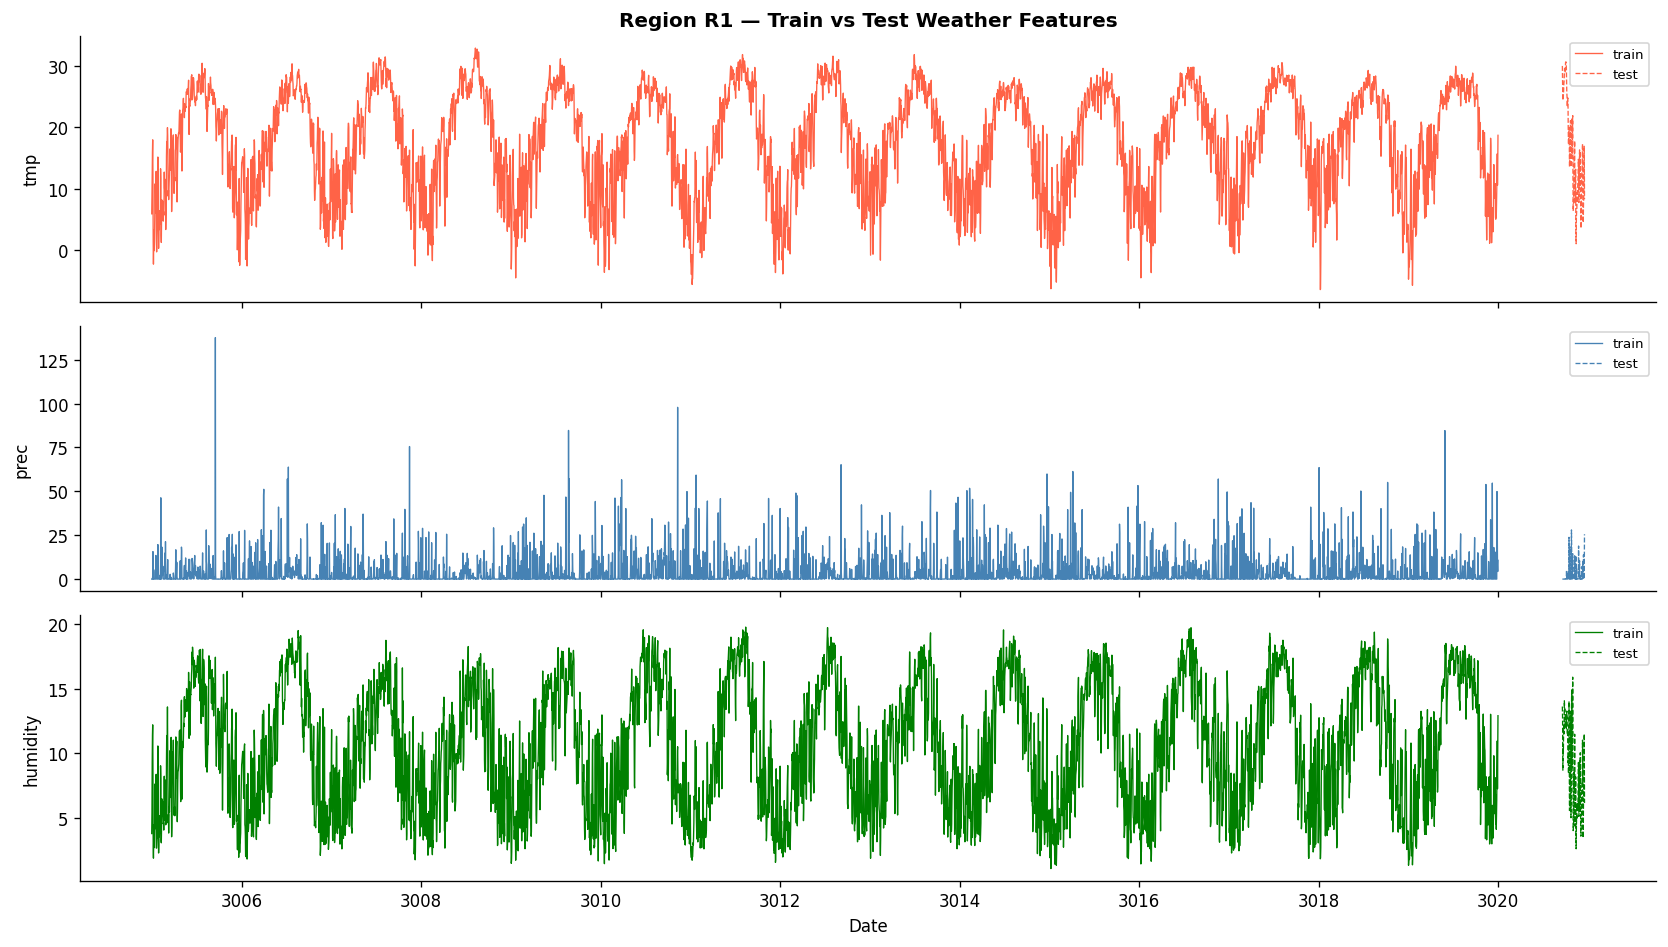

In [17]:
# Show a few weather features across train + test for one region
r1_all = pd.concat([
    r1_train[['date','tmp','prec','humidity']].assign(split='train'),
    r1_test[['date','tmp','prec','humidity']].assign(split='test'),
])

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
for ax, feat, color in zip(axes, ['tmp','prec','humidity'], ['tomato','steelblue','green']):
    for split, ls in [('train', '-'), ('test', '--')]:
        d = r1_all[r1_all['split'] == split]
        ax.plot(d['date'], d[feat], linewidth=0.8, linestyle=ls,
                color=color, label=split)
    ax.set_ylabel(feat)
    ax.legend(loc='upper right', fontsize=8)
axes[0].set_title('Region R1 — Train vs Test Weather Features', fontweight='bold')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()
